In [1]:
import random

import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

import numpy as np
from matplotlib import pyplot as plt    

import optax
import equinox as eqx 
from jax import Array, numpy as jnp, random as jr, nn

from qwen import QwenModel, utils, generate, forward


In [2]:
def train_model(model, inputs, targets, callback, epochs):
    optimizer = optax.chain(
        optax.clip_by_global_norm(1.0),
        optax.adamw(3e-4, b1=0.9, b2=0.98, weight_decay=0.01),
    )
    opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

    def loss_fn(model, inputs, targets):
        logits = forward(model, inputs)
        return optax.softmax_cross_entropy_with_integer_labels(logits, targets).mean()

    @eqx.filter_jit
    def step(model, opt_state, inputs, targets):
        loss, grads = eqx.filter_value_and_grad(loss_fn)(model, inputs, targets)
        updates, opt_state = optimizer.update(grads, opt_state, model)

        model = eqx.apply_updates(model, updates)
        return model, opt_state, loss

    for epoch in range(epochs):
        total_loss = 0.0
        for batch_inputs, batch_targets in zip(inputs, targets):
            model, opt_state, loss = step(model, opt_state, batch_inputs, batch_targets)
            total_loss = total_loss + loss

        if epoch % 50 == 0:
            callback(model, total_loss / len(inputs))
    return model


def load_dataset(seq_len):
    data = np.load("data.npy")
    data = jnp.array(data)
    data = jnp.argmax(data, axis=-1)
    states = data[:, 0] * 16 + data[:, 1]
    N = states.shape[0]
    split = int(0.8 * N)
    train_states = states[:split]
    test_states = states[split:]
    B = train_states.shape[0] // (seq_len + 1)
    L = B * (seq_len + 1)
    train_states = train_states[:L]
    sequences = train_states.reshape(B, seq_len + 1)
    inputs = sequences[:, :-1]
    targets = sequences[:, 1:]
    return inputs[None, ...], targets[None, ...], test_states


def evaluate(model, test, context_len=128, max_tokens=128):
    start = random.choice(range(test.shape[0] - max_tokens))
    true_traj = test[start : start + context_len + max_tokens]
    context = true_traj[:context_len]
    generated = generate(model, jnp.array([context]), max_tokens=max_tokens)[0]
    plt.figure(figsize=(4, 3))
    plt.plot(generated, label="model")
    plt.plot(true_traj, label="true")
    plt.legend()
    plt.show()

5.781124


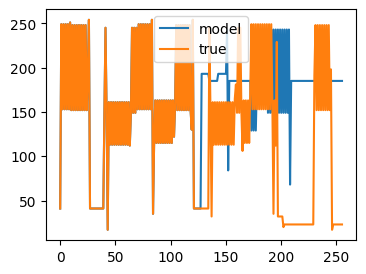

1.6176181


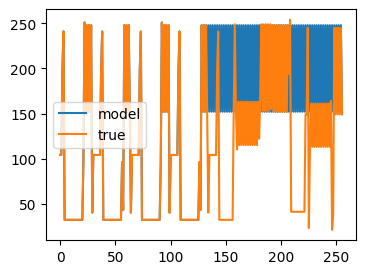

0.6939018


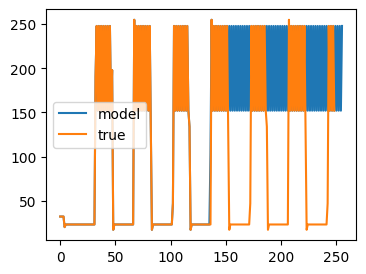

0.37876922


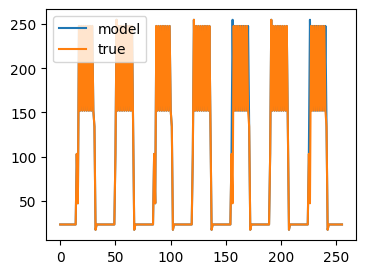

0.2010588


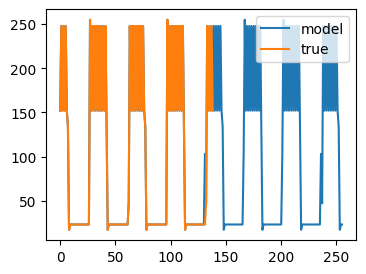

0.1114757


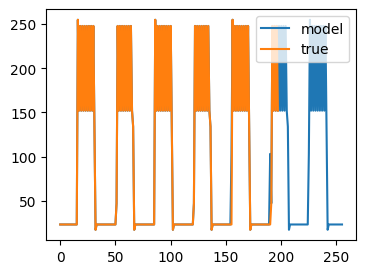

0.064675234


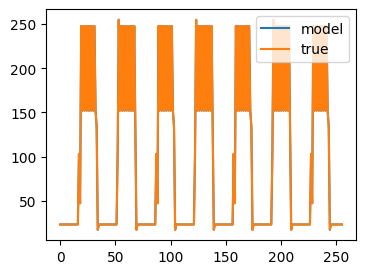

0.04295673


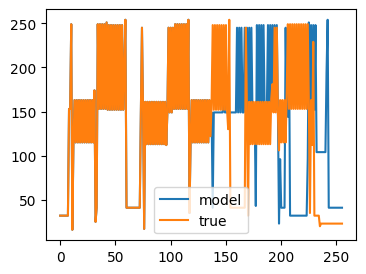

0.029504154


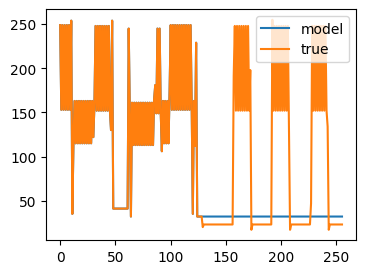

0.024070017


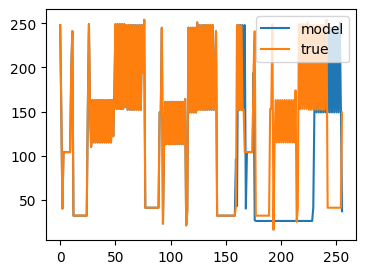

0.016889678


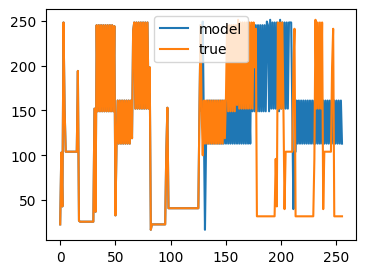

0.01147209


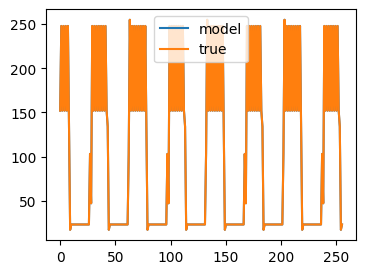

0.010060941


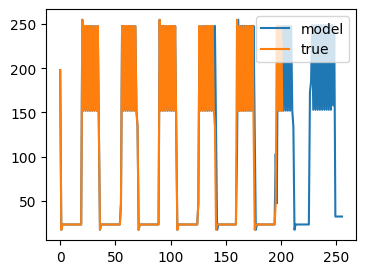

0.011890052


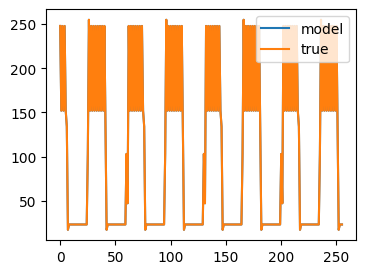

0.008718561


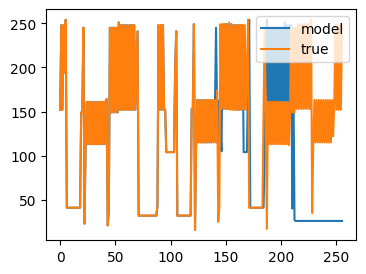

0.008163683


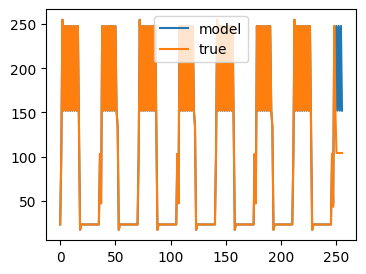

0.007960874


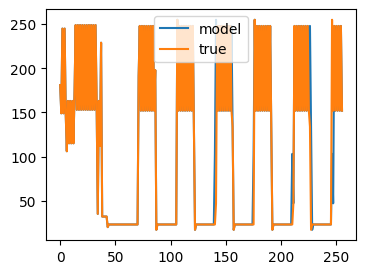

0.00784896


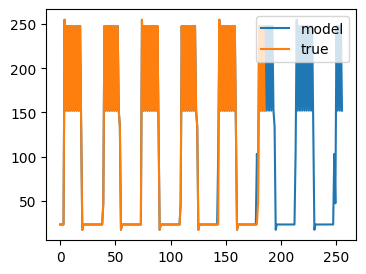

0.0077166315


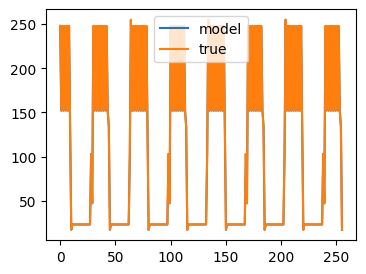

0.007675262


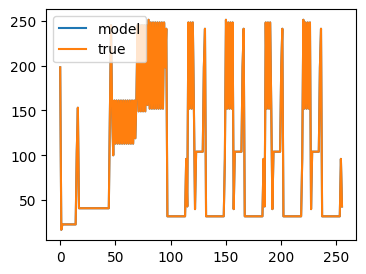

0.007611576


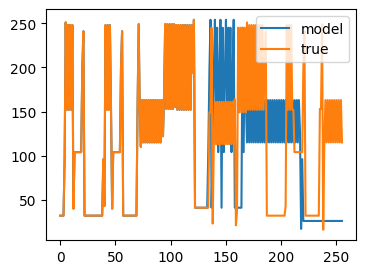

0.007581926


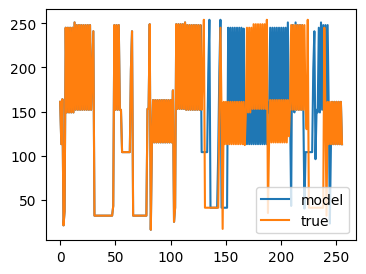

0.0075732428


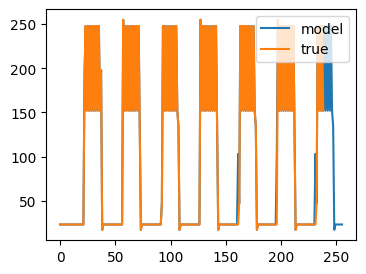

0.007531535


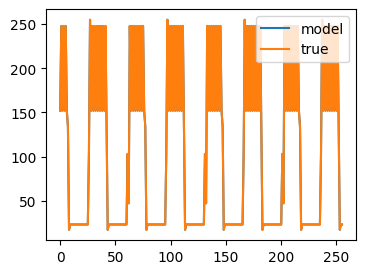

0.0075305123


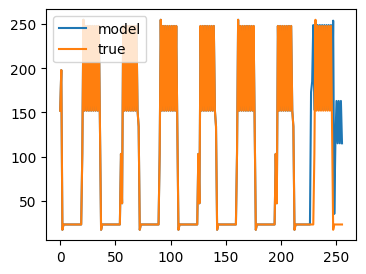

0.0075321863


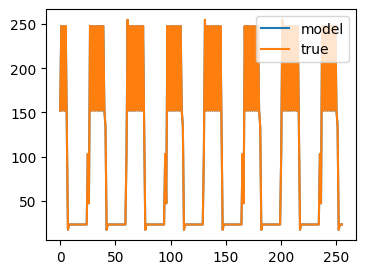

0.0075140838


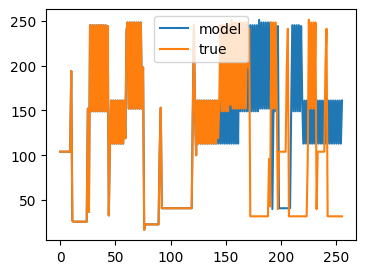

0.0075233886


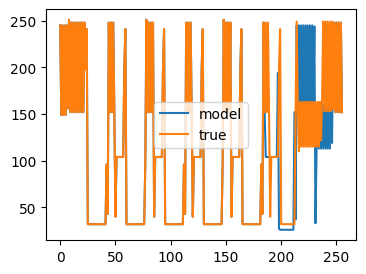

0.033995617


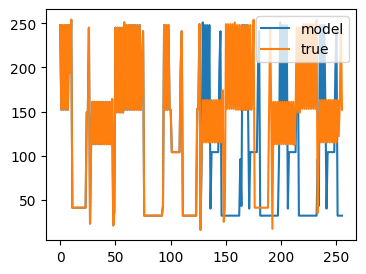

0.0076067736


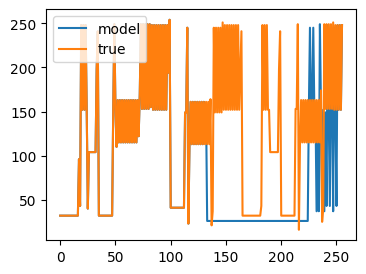

0.0075082593


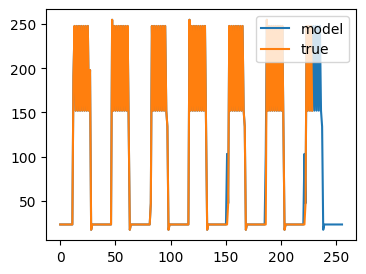

0.0074987873


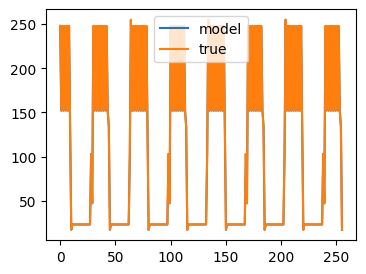

0.0074962457


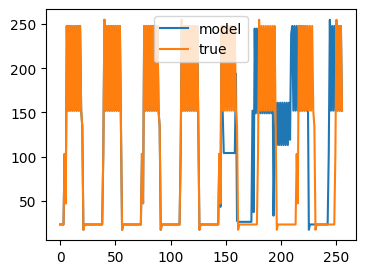

0.0074935295


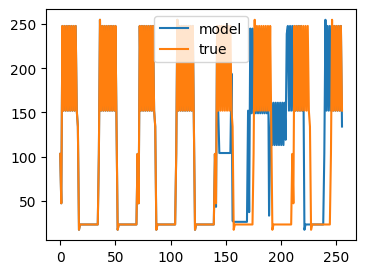

0.007502422


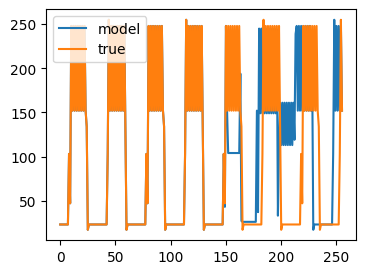

0.007500833


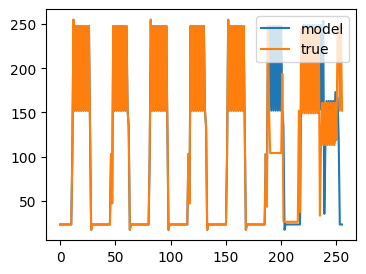

0.007493323


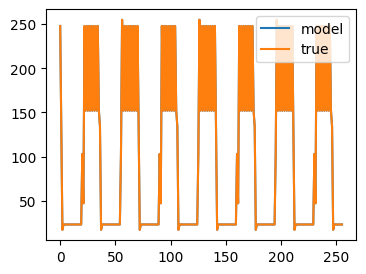

0.0074908654


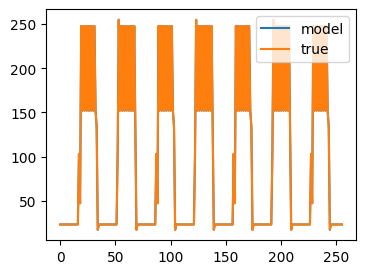

0.0074874493


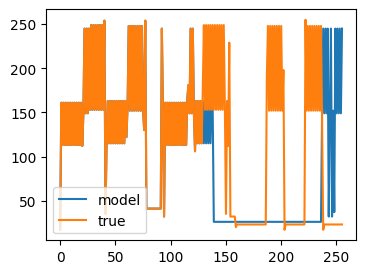

0.0074939593


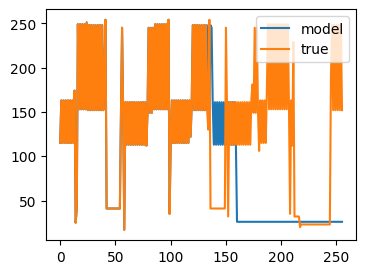

0.007485364


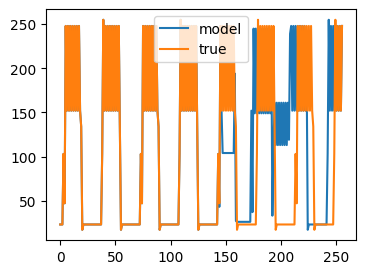

0.0074842065


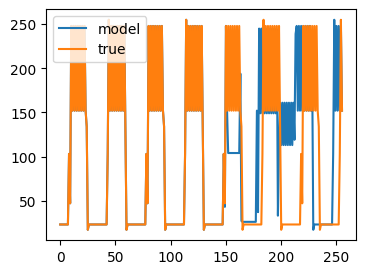

0.0074914116


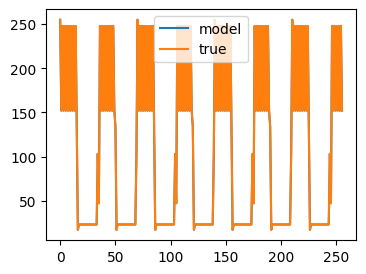

0.0074835424


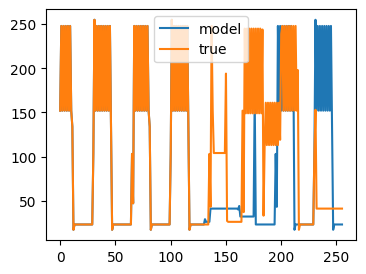

0.007483539


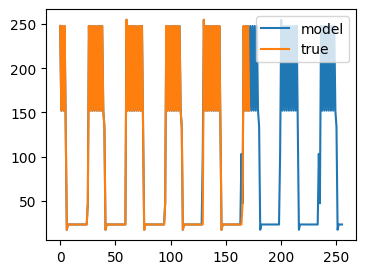

0.0074829096


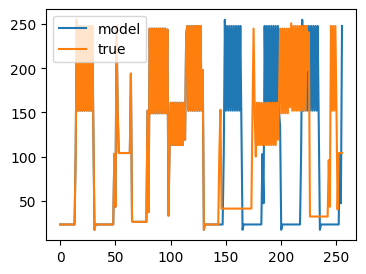

0.007483844


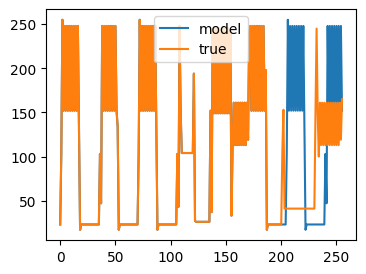

0.007484546


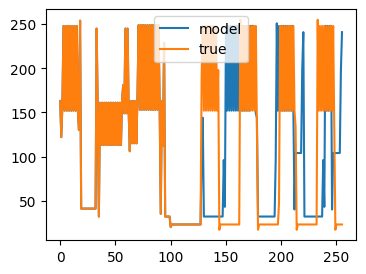

0.017382495


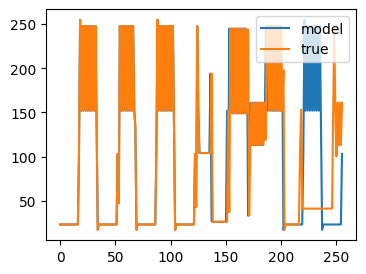

0.007535478


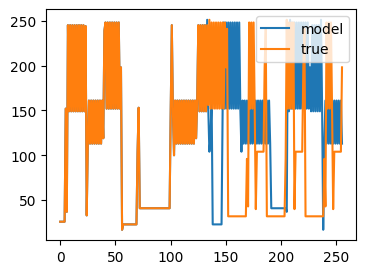

0.007488693


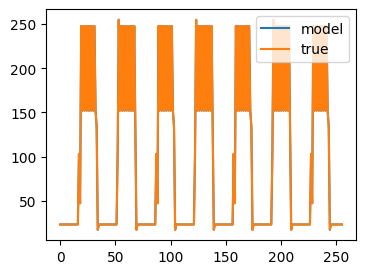

0.007484958


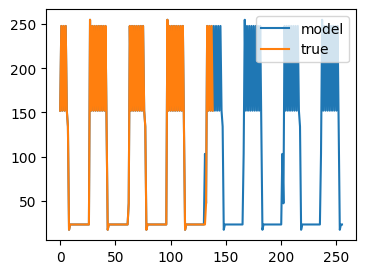

0.007482922


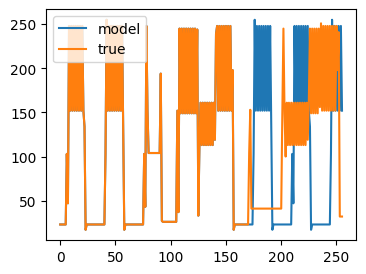

0.007516165


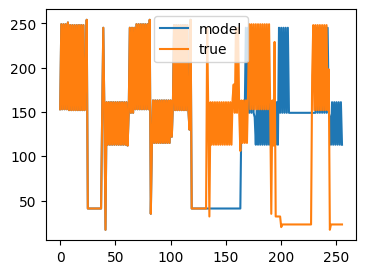

0.007481185


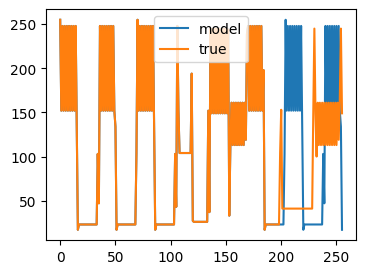

0.0074823657


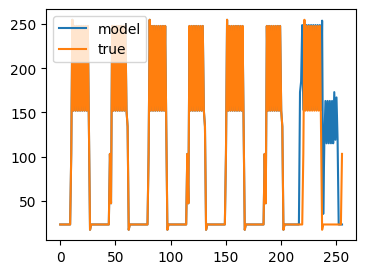

0.0074809077


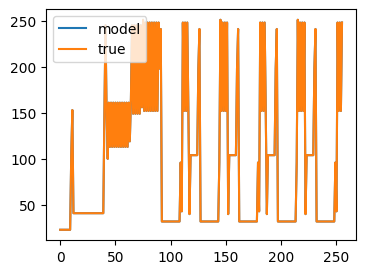

0.007482101


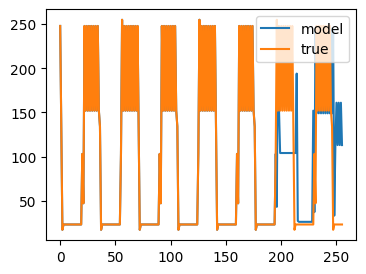

0.0074907406


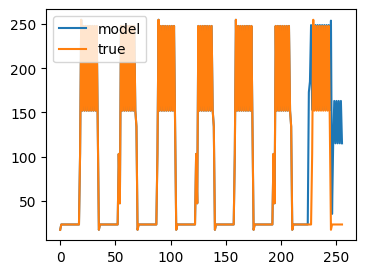

0.007481332


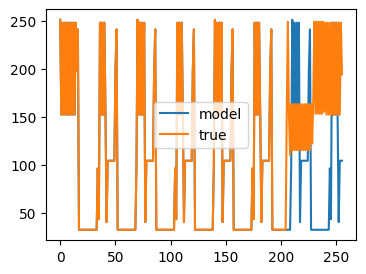

0.00748186


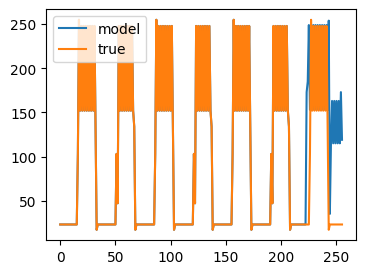

0.0074823154


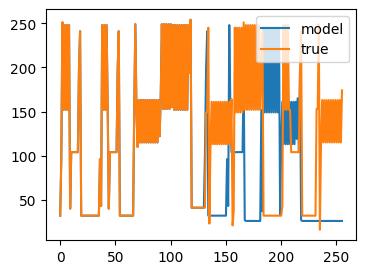

0.007486533


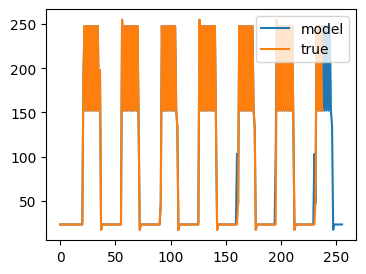

0.0074802283


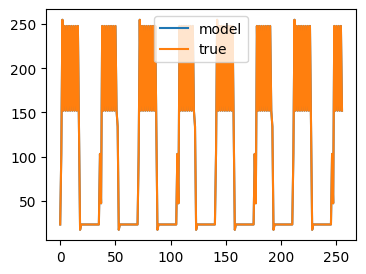

0.007479247


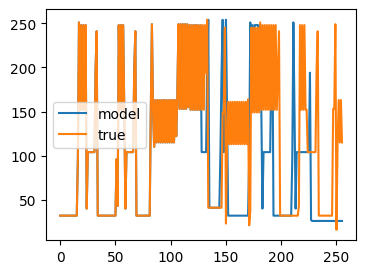

0.00748319


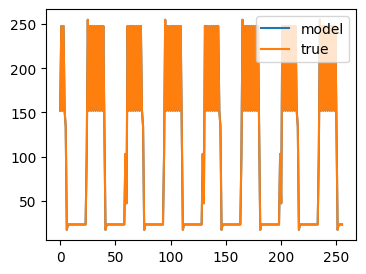

0.007480037


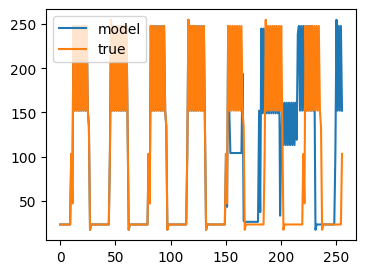

0.007480033


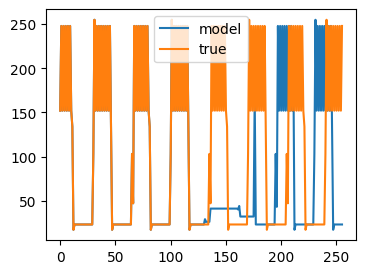

0.00747996


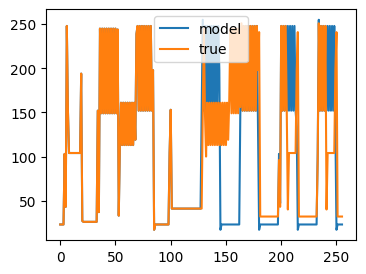

0.0074797096


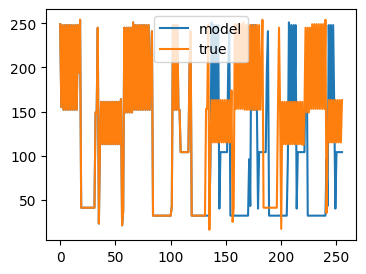

0.0074796034


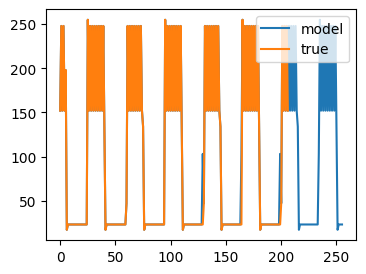

0.007484567


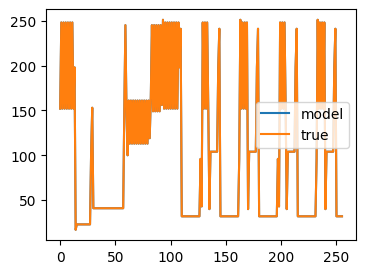

0.007630107


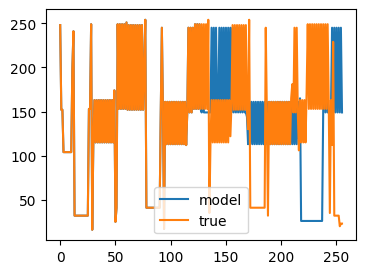

0.007483096


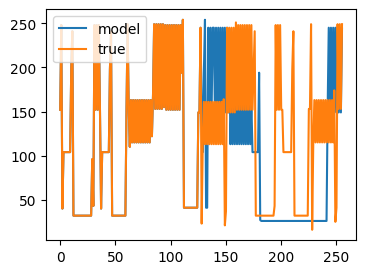

0.007481139


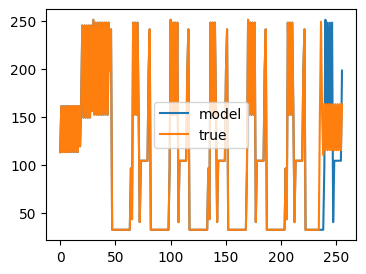

0.0074801105


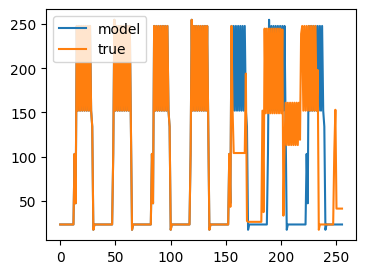

0.0074793813


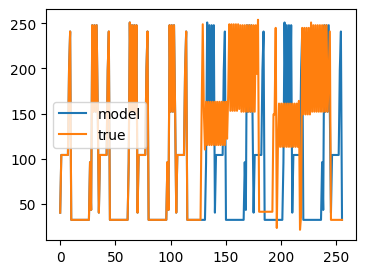

0.0074790786


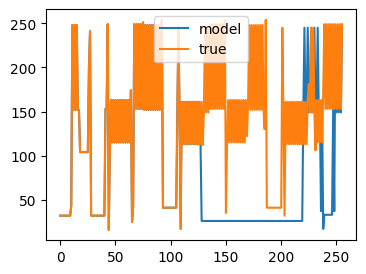

0.00747952


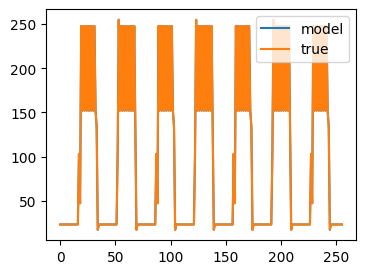

0.0074795447


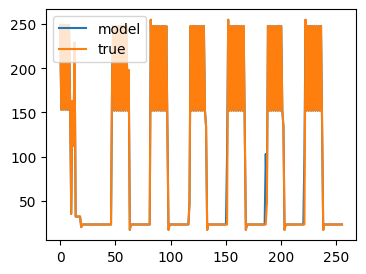

0.0074807773


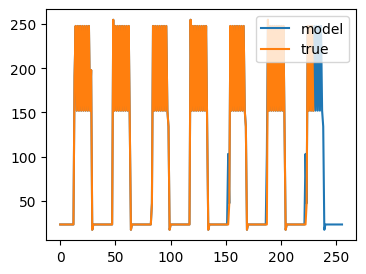

0.0074797245


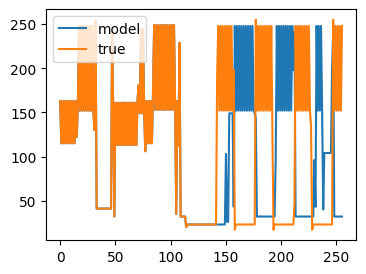

0.0074823606


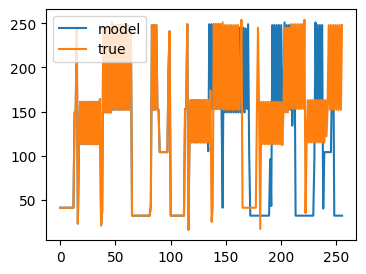

0.0074806134


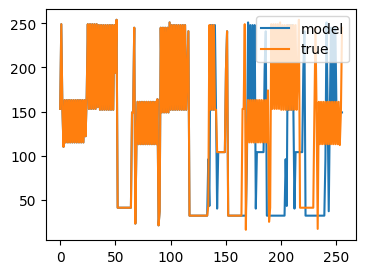

0.007478994


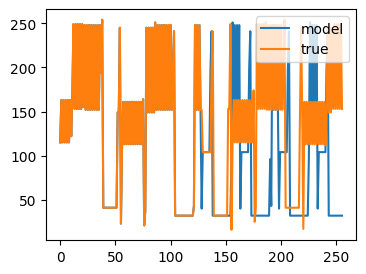

0.0074789464


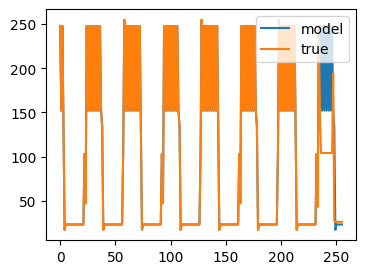

0.0074832947


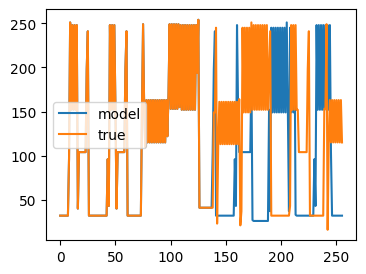

0.0074783014


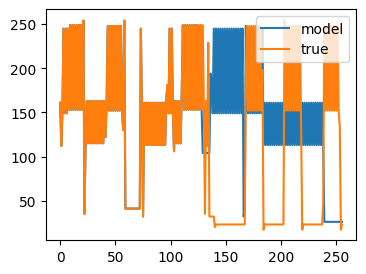

0.007479087


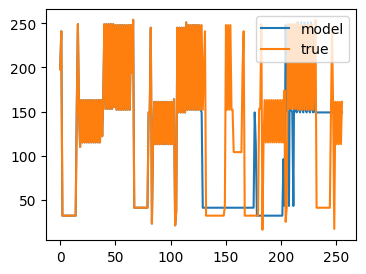

0.0074791326


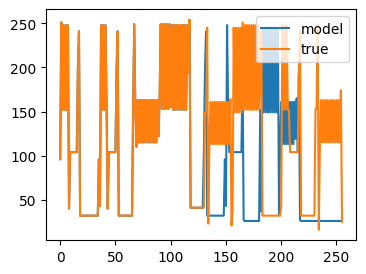

0.007478706


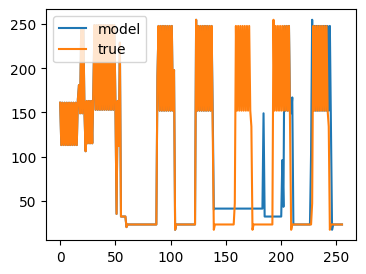

0.007478676


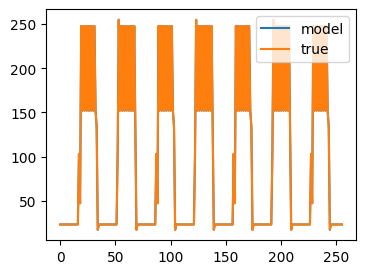

0.0074778674


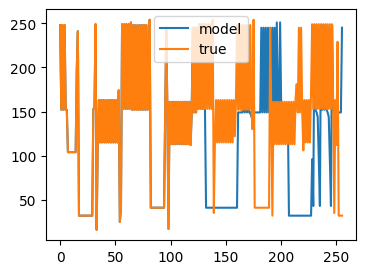

In [3]:
key = jr.PRNGKey(0)
model = utils.init(
    key,
    vocab_size=256,
    hidden_size=64,
    num_layers=4,
    num_heads=2,
    num_key_value_heads=2,
    rope_theta=10000.0,
    rms_norm_eps=1e-6,
)

inputs, targets, test = load_dataset(seq_len=256)

def eval_callback(model, loss):
    print(loss)
    evaluate(model, test)

model = train_model(model, inputs, targets, eval_callback, epochs=10000)